## Relación entre ventas y personal activo

## HISTORICO

In [37]:
# Cargamos los datos de ventas

import pandas as pd

ventas_2024 = pd.read_csv(
    "data/sales_hourly/sales_per_hour_2024.csv"
)

ventas_2025 = pd.read_csv(
    "data/sales_hourly/sales_per_hour_2025.csv"
)

ventas_2026 = pd.read_csv(
    "data/sales_hourly/sales_per_hour_2026.csv"
)

ventas = pd.concat(
    [ventas_2024, ventas_2025, ventas_2026],
    ignore_index=True
)

ventas["datetime"] = pd.to_datetime(
    ventas["datetime"]
)

ventas.head()

,datetime,ventas
0,2024-01-01 15:00:00,200.6
1,2024-01-01 16:00:00,174.9
2,2024-01-01 17:00:00,204.9
3,2024-01-01 18:00:00,282.2
4,2024-01-01 19:00:00,249.8


In [38]:
# Cargamos los turnos de trabajo

horarios = pd.read_excel("data/inputs/horarios.xlsx")

horarios["fecha"] = pd.to_datetime(
    horarios["fecha"],
    dayfirst=True
)

horarios["entrada"] = pd.to_datetime(
    horarios["entrada"].astype(str),
    format="%H:%M:%S"
).dt.time

horarios["duracion_turno"] = (
    horarios["duracion_turno"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

horarios.head()

,semana,dia,fecha,worker_id,entrada,duracion_turno
0,1,1,2024-08-05,0,18:00:00,8.0
1,1,1,2024-08-05,2,13:00:00,8.0
2,1,1,2024-08-05,3,12:30:00,8.0
3,1,1,2024-08-05,5,18:30:00,7.5
4,1,1,2024-08-05,8,12:30:00,9.0


In [39]:
# Transformamos los turnos en registros por hora

from datetime import timedelta

registros = []

for _, fila in horarios.iterrows():

    inicio = pd.Timestamp.combine(
        fila["fecha"],
        fila["entrada"]
    )

    fin = inicio + timedelta(
        hours=fila["duracion_turno"]
    )

    hora = inicio.floor("h")

    while hora < fin:

        registros.append({
            "datetime": hora
        })

        hora += timedelta(hours=1)

personas = (
    pd.DataFrame(registros)
      .groupby("datetime")
      .size()
      .reset_index(name="personas")
)

personas.head()

,datetime,personas
0,2024-08-05 12:00:00,2
1,2024-08-05 13:00:00,3
2,2024-08-05 14:00:00,3
3,2024-08-05 15:00:00,3
4,2024-08-05 16:00:00,3


In [40]:
# COnstruimos dataset con ventas y personal

df = ventas.merge(
    personas,
    on="datetime",
    how="inner"
)

df.head()

,datetime,ventas,personas
0,2024-08-05 12:00:00,42.9,2
1,2024-08-05 13:00:00,84.6,3
2,2024-08-05 14:00:00,103.6,3
3,2024-08-05 15:00:00,194.7,3
4,2024-08-05 16:00:00,314.1,3


In [41]:
# Limpieza del dataset

df = df[
    (df["ventas"] >= 1)
    &
    (df["personas"] > 0)
].copy()

df.reset_index(drop=True, inplace=True)

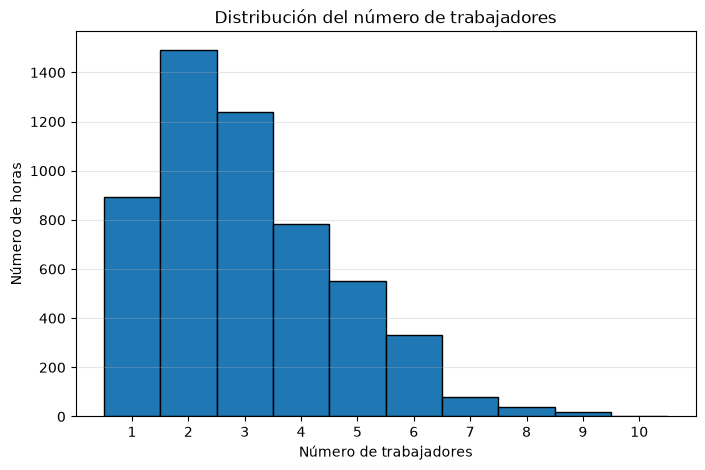

In [42]:
# Histograma del número de trabajadores

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["personas"],
    bins=range(
        int(df["personas"].min()),
        int(df["personas"].max()) + 2
    ),
    edgecolor="black",
    align="left"
)

plt.xticks(
    range(
        int(df["personas"].min()),
        int(df["personas"].max()) + 1
    )
)

plt.xlabel("Número de trabajadores")
plt.ylabel("Número de horas")
plt.title("Distribución del número de trabajadores")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [43]:
# Frecuencia del número de trabajadores

frecuencias = (
    df["personas"]
    .value_counts()
    .sort_index()
    .rename("Horas")
    .to_frame()
)

frecuencias["Porcentaje"] = (
    frecuencias["Horas"]
    / frecuencias["Horas"].sum()
    * 100
).round(2)

frecuencias

,Horas,Porcentaje
personas,,
1,895,16.49
2,1492,27.49
3,1237,22.79
4,784,14.45
5,553,10.19
6,330,6.08
7,79,1.46
8,37,0.68
9,17,0.31


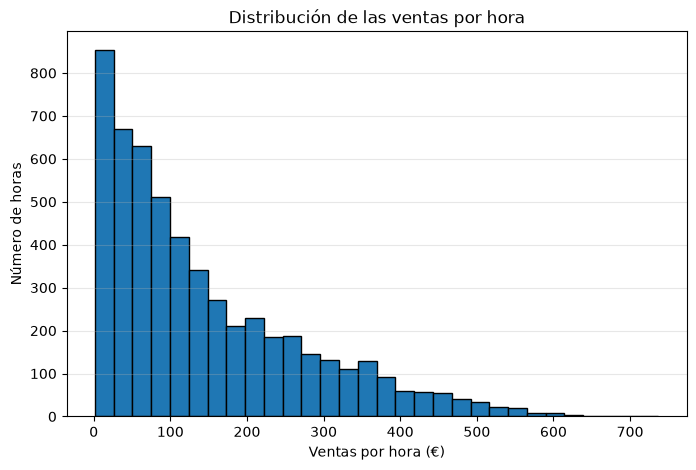

In [44]:
# Histograma de las ventas por hora

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["ventas"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Ventas por hora (€)")
plt.ylabel("Número de horas")
plt.title("Distribución de las ventas por hora")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [45]:
df["ventas"].describe().round(2)

count    5427.00
mean      144.10
std       128.84
min         1.40
25%        43.95
50%       102.10
75%       213.85
max       737.00
Name: ventas, dtype: float64

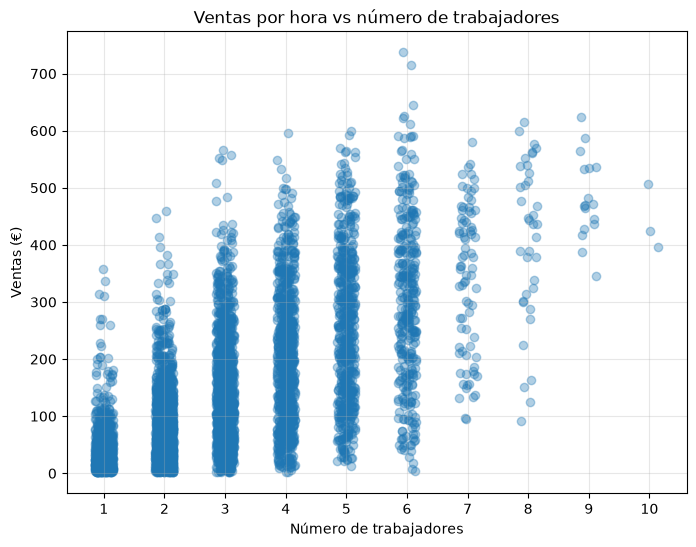

In [46]:
# Relación entre ventas y número de trabajadores. Scatter plot

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

x = (
    df["personas"]
    + np.random.uniform(-0.15, 0.15, len(df))
)

plt.scatter(
    x,
    df["ventas"],
    alpha=0.35
)

plt.xticks(sorted(df["personas"].unique()))

plt.xlabel("Número de trabajadores")
plt.ylabel("Ventas (€)")
plt.title("Ventas por hora vs número de trabajadores")

plt.grid(alpha=0.3)

plt.show()

<Figure size 1000x600 with 0 Axes>

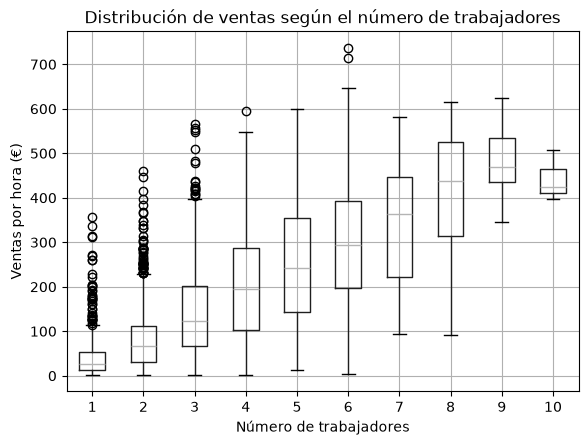

In [47]:
# Boxplot de ventas por número de trabajadores

plt.figure(figsize=(10,6))

df.boxplot(column="ventas", by="personas")

plt.xlabel("Número de trabajadores")
plt.ylabel("Ventas por hora (€)")
plt.title("Distribución de ventas según el número de trabajadores")
plt.suptitle("")
plt.show()

In [48]:
# Tabla ventas por nuemro de trabajador

resumen = (
    df.groupby("personas")
      .agg(
          horas=("ventas","count"),
          venta_media=("ventas","mean"),
          venta_mediana=("ventas","median"),
          venta_std=("ventas","std"),
          venta_min=("ventas","min"),
          venta_max=("ventas","max")
      )
      .round(2)
)

resumen

,horas,venta_media,venta_mediana,venta_std,venta_min,venta_max
personas,,,,,,
1,895,40.55,27.00,43.62,1.8,357.7
2,1492,80.42,67.55,64.85,1.4,459.9
3,1237,142.51,122.70,97.57,1.5,566.3
4,784,202.34,194.80,117.97,1.8,595.7
5,553,254.08,241.80,132.23,12.4,600.1
6,330,298.56,293.35,144.44,4.1,737.0
7,79,343.36,363.40,128.32,94.3,581.0
8,37,409.79,437.50,140.71,91.9,616.1
9,17,482.30,470.30,73.10,345.2,623.4


In [49]:
# Tabla ventas por horas

resumen_hora = (
    df.groupby(df["datetime"].dt.hour)
      .agg(
          horas=("ventas", "count"),
          ventas_medias=("ventas", "mean"),
          ventas_mediana=("ventas", "median"),
          trabajadores_medios=("personas", "mean")
      )
      .round(2)
)

resumen_hora["ventas_por_trabajador"] = (
    resumen_hora["ventas_medias"] /
    resumen_hora["trabajadores_medios"]
).round(2)

resumen_hora

,horas,ventas_medias,ventas_mediana,trabajadores_medios,ventas_por_trabajador
datetime,,,,,
0,176,116.04,90.00,2.65,43.79
1,39,36.68,30.60,2.77,13.24
12,309,21.01,15.20,1.08,19.45
13,399,39.56,30.60,1.46,27.10
14,433,68.54,56.00,1.64,41.79
15,452,139.44,106.85,2.60,53.63
16,457,178.40,136.10,3.23,55.23
17,458,180.96,143.10,3.98,45.47
18,459,231.14,203.70,4.36,53.01


Aqui hay un punto importante que veo, entre las 19:00 y las 20:00 las ventas caen un 32% pero el numero medio de trabadores sigue identico, suponemos que por esperar a despues de cenas, pero en verdad no repunta tanto, solo hasta 136

Las 22:00 la hora mas productiva del dia, 64 euros por trabajador

In [50]:
dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

df["hora"] = df["datetime"].dt.hour
df["dia_semana"] = df["datetime"].dt.dayofweek.map(dias)

df["dia_semana"] = pd.Categorical(
    df["dia_semana"],
    categories=orden_dias,
    ordered=True
)

orden_horas = [
    12, 13, 14, 15, 16, 17, 18, 19,
    20, 21, 22, 23, 0, 1
]

ventas_hora_dia = pd.pivot_table(
    df,
    values="ventas",
    index="hora",
    columns="dia_semana",
    aggfunc="mean"
).reindex(orden_horas).round(1)

ventas_hora_dia

dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
hora,,,,,,,
12,16.2,19.6,15.2,14.9,18.9,24.9,31.0
13,29.6,29.4,32.0,24.3,33.3,47.0,69.4
14,47.2,60.2,45.5,48.5,56.5,86.9,122.9
15,83.0,115.2,91.3,100.6,114.3,199.3,253.1
16,113.2,147.8,109.9,113.0,159.8,258.4,325.4
17,122.8,170.8,126.2,137.2,169.1,237.9,292.7
18,175.4,241.4,168.6,185.2,235.5,278.6,333.1
19,174.4,227.0,159.7,194.6,254.8,265.0,317.6
20,115.9,164.1,109.8,123.6,176.5,186.9,212.8


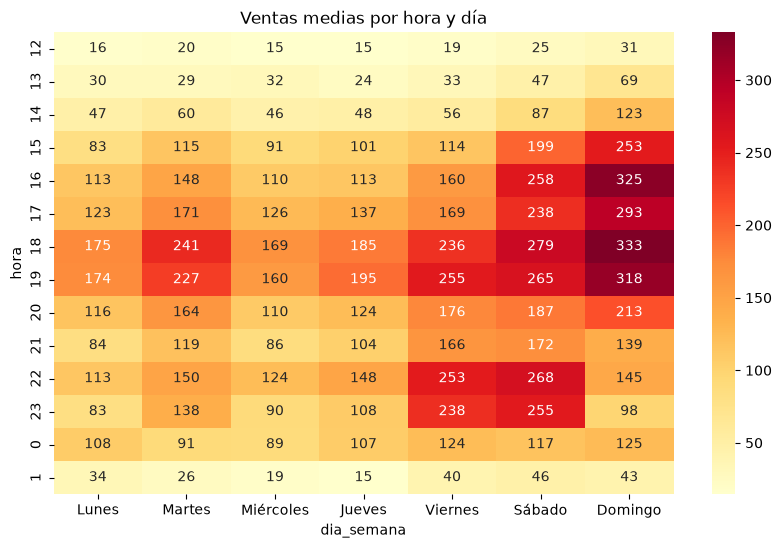

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    ventas_hora_dia,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Ventas medias por hora y día")
plt.show()

In [52]:
orden_horas = [
    12, 13, 14, 15, 16, 17, 18, 19,
    20, 21, 22, 23, 0, 1
]

trabajadores_hora_dia = pd.pivot_table(
    df,
    values="personas",
    index="hora",
    columns="dia_semana",
    aggfunc="mean"
).reindex(orden_horas).round(2)

trabajadores_hora_dia

productividad = (
    ventas_hora_dia /
    trabajadores_hora_dia
).round(1)

productividad

dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
hora,,,,,,,
12,15.9,18.8,14.1,13.3,17.5,22.2,28.7
13,22.1,23.5,26.2,19.3,25.4,28.1,35.2
14,32.8,46.0,33.2,34.9,40.1,42.2,54.9
15,37.6,51.9,44.3,44.9,49.3,64.7,66.3
16,41.0,60.6,43.6,41.7,52.1,64.0,70.0
17,38.1,55.1,40.7,41.7,40.6,45.4,55.9
18,50.0,69.8,50.2,51.9,47.0,49.3,60.8
19,49.4,65.0,47.5,54.2,50.4,46.8,58.0
20,32.8,47.0,32.7,34.4,34.9,33.2,39.0


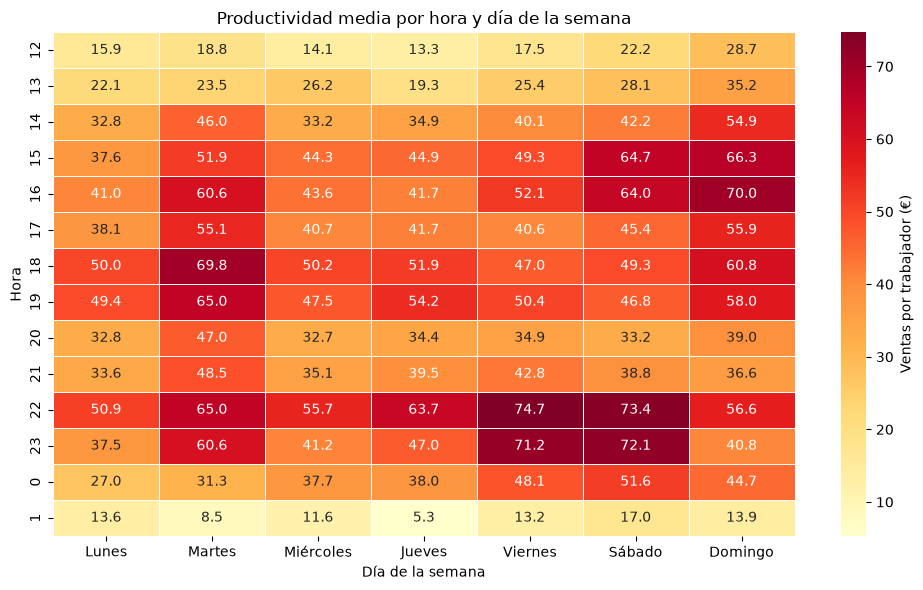

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    productividad,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Ventas por trabajador (€)"}
)

plt.title("Productividad media por hora y día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Hora")

plt.tight_layout()
plt.show()

## Histograma doble ventas, trabajadores por horas

In [54]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Resumen por hora
comparacion = (
    df.groupby(df["datetime"].dt.hour)
      .agg(
          ventas=("ventas", "mean"),
          trabajadores=("personas", "mean")
      )
)

# Normalización
scaler = MinMaxScaler()

comparacion[["ventas_norm", "trabajadores_norm"]] = scaler.fit_transform(
    comparacion[["ventas", "trabajadores"]]
)

comparacion

,ventas,trabajadores,ventas_norm,trabajadores_norm
datetime,,,,
0,116.039205,2.647727,0.452260,0.474937
1,36.676923,2.769231,0.074579,0.511768
12,21.005502,1.080906,0.000000,0.000000
13,39.561404,1.463659,0.088306,0.116021
14,68.541801,1.637413,0.226222,0.168689
15,139.435841,2.599558,0.563603,0.460336
16,178.404595,3.229759,0.749053,0.651364
17,180.959214,3.975983,0.761210,0.877560
18,231.136383,4.361656,1.000000,0.994466


In [55]:
orden_horas = [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1]

comparacion = comparacion.loc[orden_horas]
comparacion = comparacion.reindex(orden_horas)

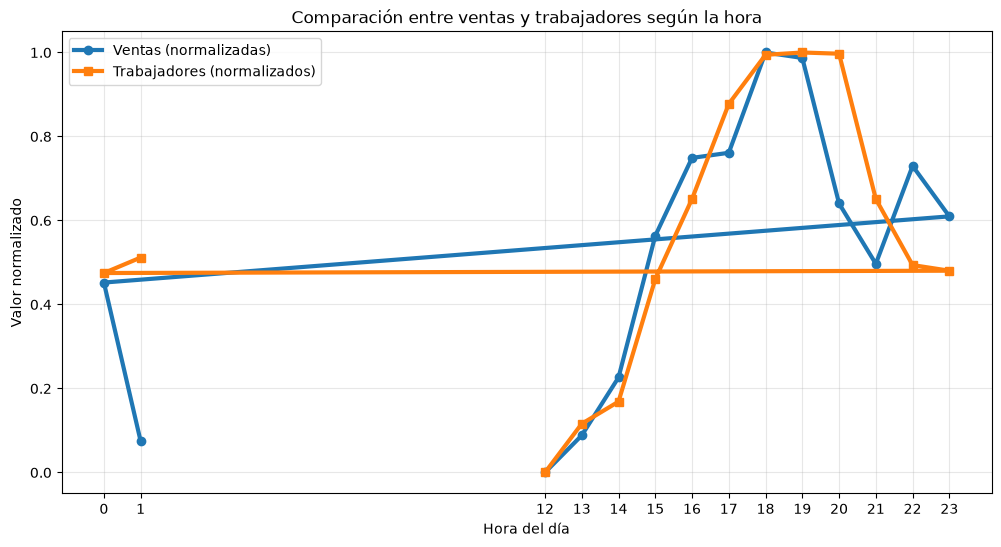

In [56]:
plt.figure(figsize=(12,6))

plt.plot(
    comparacion.index,
    comparacion["ventas_norm"],
    marker="o",
    linewidth=3,
    label="Ventas (normalizadas)"
)

plt.plot(
    comparacion.index,
    comparacion["trabajadores_norm"],
    marker="s",
    linewidth=3,
    label="Trabajadores (normalizados)"
)

plt.xticks(comparacion.index)

plt.xlabel("Hora del día")
plt.ylabel("Valor normalizado")
plt.title("Comparación entre ventas y trabajadores según la hora")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

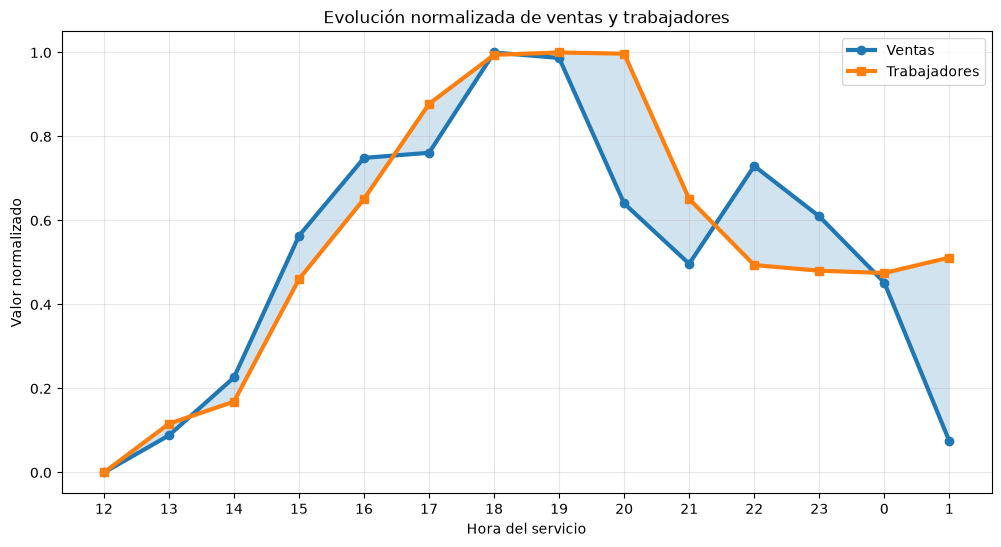

In [57]:
x = range(len(comparacion))

plt.figure(figsize=(12,6))

plt.plot(
    x,
    comparacion["ventas_norm"],
    marker="o",
    linewidth=3,
    label="Ventas"
)

plt.plot(
    x,
    comparacion["trabajadores_norm"],
    marker="s",
    linewidth=3,
    label="Trabajadores"
)

plt.fill_between(
    x,
    comparacion["ventas_norm"],
    comparacion["trabajadores_norm"],
    alpha=0.2
)

plt.xticks(
    x,
    comparacion.index.astype(str)
)

plt.xlabel("Hora del servicio")
plt.ylabel("Valor normalizado")
plt.title("Evolución normalizada de ventas y trabajadores")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

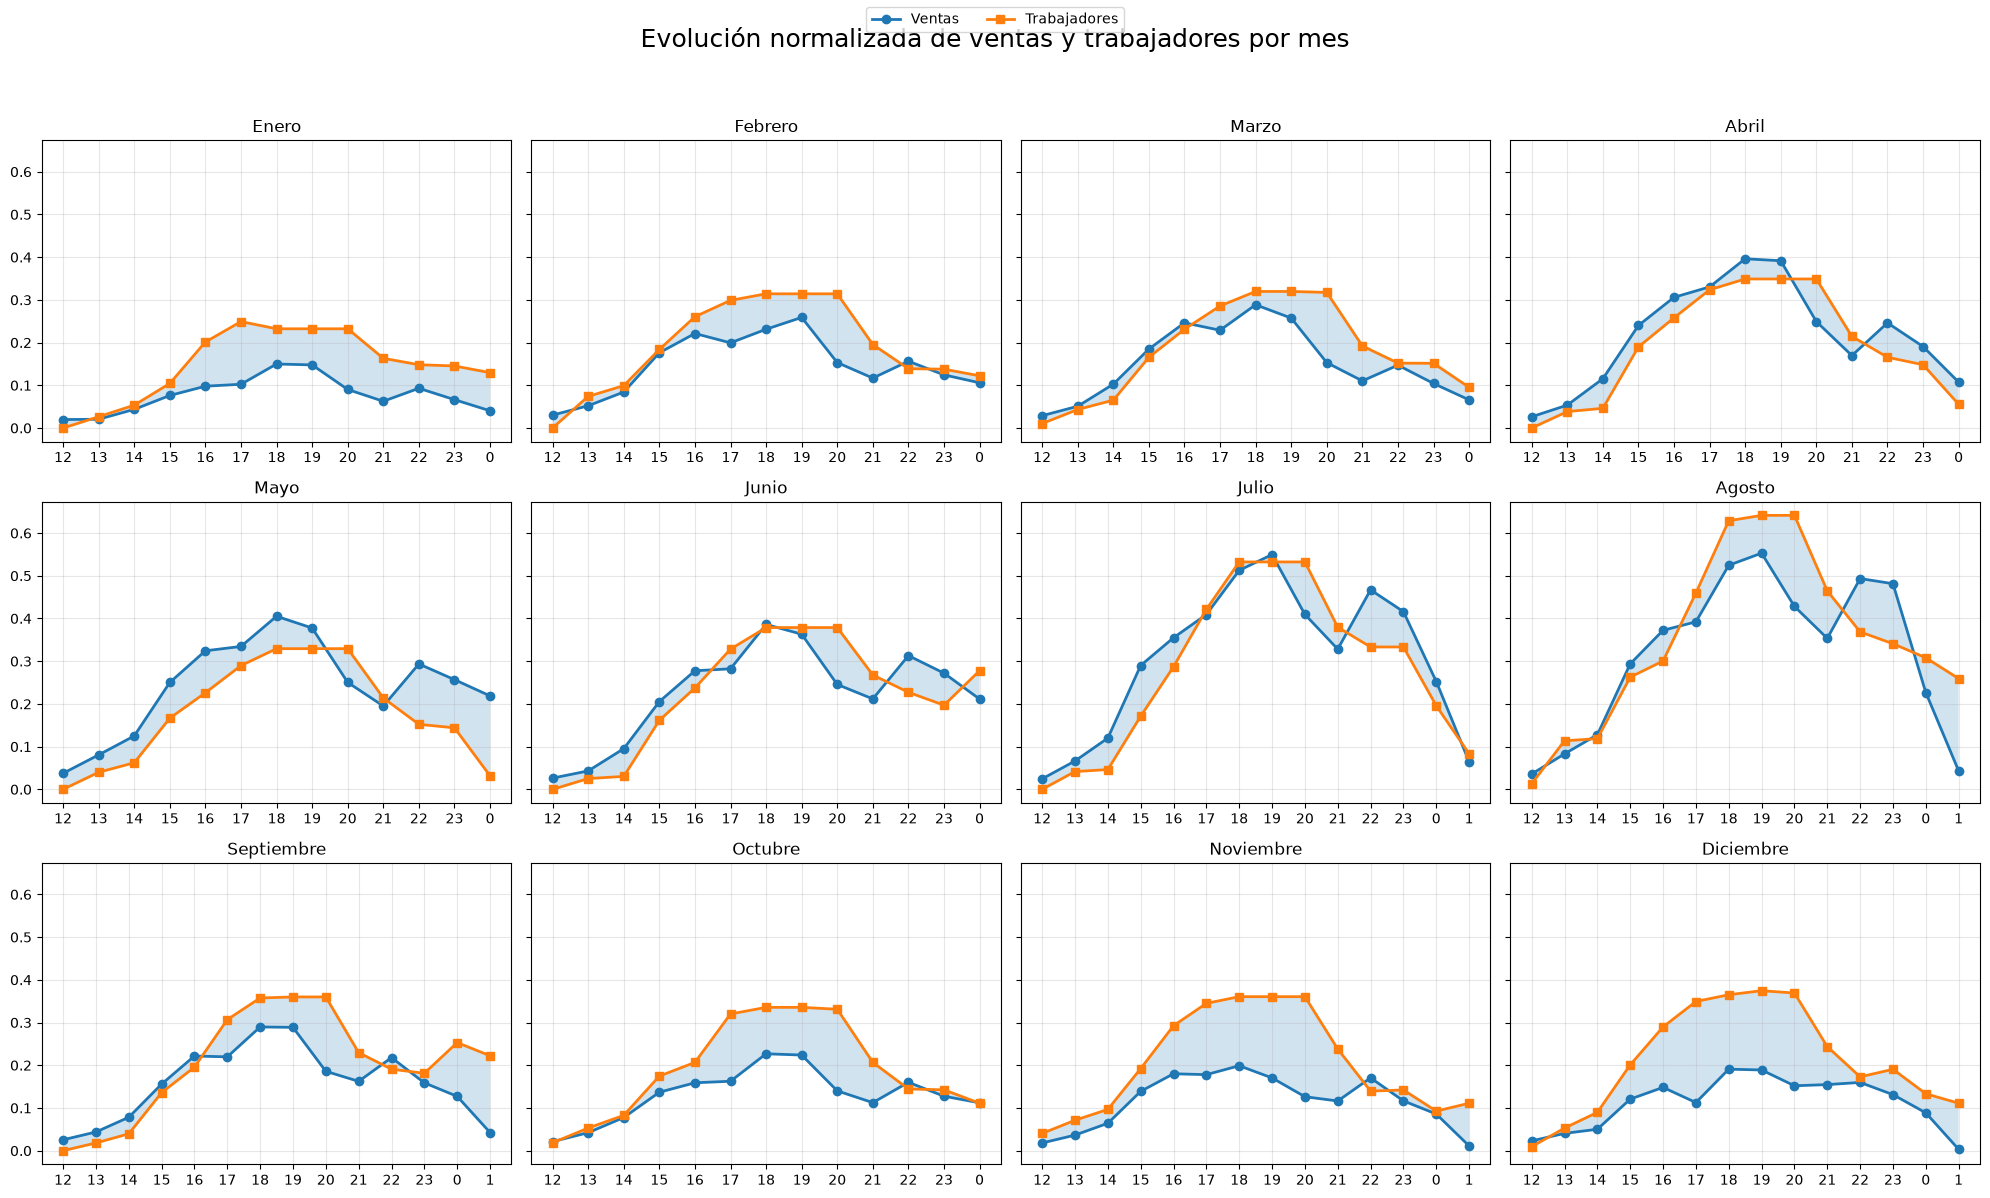

In [58]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

orden_horas = [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1]

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)

meses = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

scaler = MinMaxScaler()

df[["ventas_norm", "trabajadores_norm"]] = scaler.fit_transform(
    df[["ventas", "personas"]]
)

for mes in range(1, 13):

    datos_mes = df[df["datetime"].dt.month == mes]

    comparacion = (
        datos_mes
        .groupby(datos_mes["datetime"].dt.hour)
        .agg(
            ventas_norm=("ventas_norm", "mean"),
            trabajadores_norm=("trabajadores_norm", "mean")
        )
    )

    # Orden cronológico: 12, 13, ..., 23, 0, 1
    comparacion = comparacion.reindex(orden_horas)

    # Eliminar horas que no tengan datos
    comparacion = comparacion.dropna()

    x = range(len(comparacion))

    ax = axes[(mes-1)//4, (mes-1)%4]

    ax.plot(
        x,
        comparacion["ventas_norm"],
        marker="o",
        linewidth=2,
        label="Ventas"
    )

    ax.plot(
        x,
        comparacion["trabajadores_norm"],
        marker="s",
        linewidth=2,
        label="Trabajadores"
    )

    ax.fill_between(
        x,
        comparacion["ventas_norm"],
        comparacion["trabajadores_norm"],
        alpha=0.2
    )

    ax.set_xticks(x)
    ax.set_xticklabels(comparacion.index)

    ax.set_title(meses[mes-1])

    ax.grid(alpha=0.3)

fig.suptitle(
    "Evolución normalizada de ventas y trabajadores por mes",
    fontsize=18
)

handles, labels = axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout(rect=[0,0,1,0.95])

plt.show()

In [59]:
# ============================================
# MÉTRICA DE DESAJUSTE VENTAS - PERSONAL
# ============================================

from sklearn.preprocessing import MinMaxScaler

df_metricas = df.copy()

# Normalización común de ventas y trabajadores
scaler = MinMaxScaler()

df_metricas[
    ["ventas_norm", "trabajadores_norm"]
] = scaler.fit_transform(
    df_metricas[
        ["ventas", "personas"]
    ]
)

# Desajuste absoluto entre ventas y personal
df_metricas["desajuste"] = (
    df_metricas["ventas_norm"]
    - df_metricas["trabajadores_norm"]
).abs()

# Obtener mes directamente desde la fecha
df_metricas["mes"] = df_metricas["datetime"].dt.month

# Desajuste medio por mes
desajuste_mensual_historico = (
    df_metricas
    .groupby("mes")["desajuste"]
    .mean()
)

# Desajuste global
desajuste_global_historico = (
    df_metricas["desajuste"].mean()
)

print("DESAJUSTE HISTÓRICO")
print("===================")

print("\nPor mes:")
print(
    desajuste_mensual_historico.round(4)
)

print(
    f"\nGlobal: {desajuste_global_historico:.4f}"
)

DESAJUSTE HISTÓRICO

Por mes:
mes
1     0.0930
2     0.0966
3     0.1106
4     0.1114
5     0.1103
6     0.0947
7     0.1043
8     0.1250
9     0.0868
10    0.1086
11    0.1279
12    0.1322
Name: desajuste, dtype: float64

Global: 0.1095


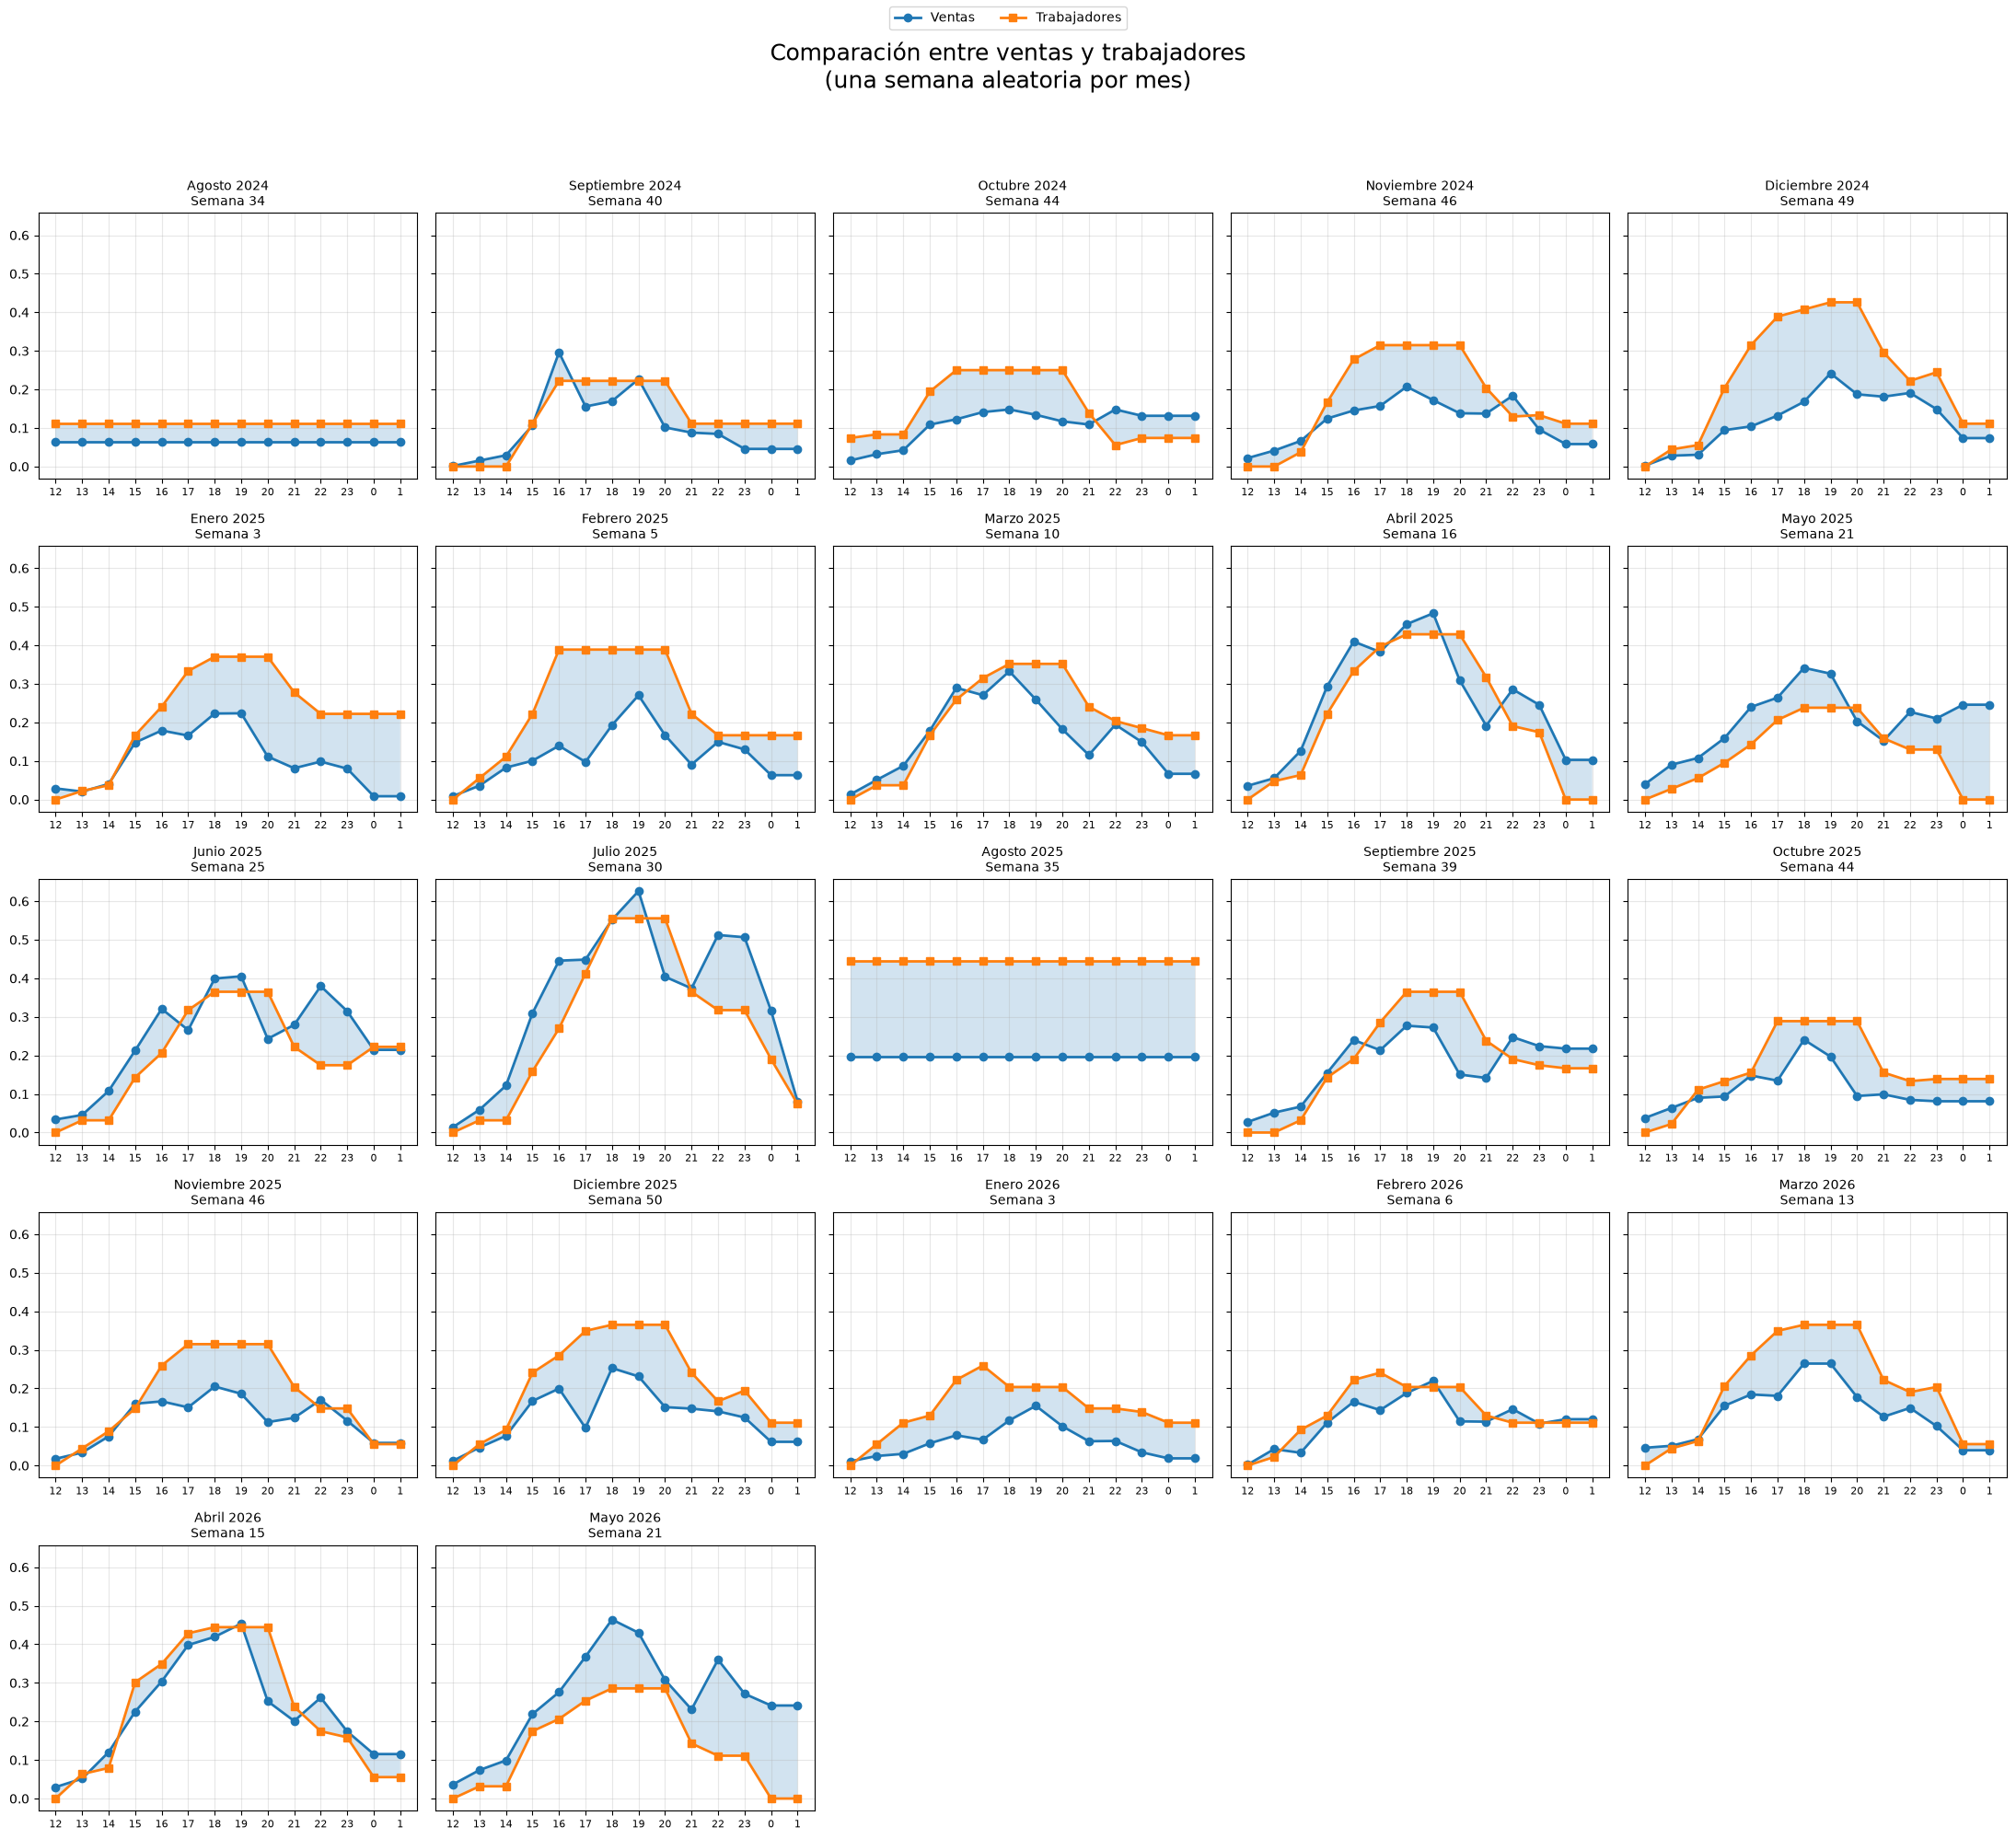

In [60]:
import numpy as np

np.random.seed(42)

# Orden de las horas del servicio
orden_horas = [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1]

# Año y semana ISO
df["anio"] = df["datetime"].dt.year
df["mes"] = df["datetime"].dt.month
df["semana"] = df["datetime"].dt.isocalendar().week

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["ventas_norm", "trabajadores_norm"]] = scaler.fit_transform(
    df[["ventas", "personas"]]
)

# Semilla para que siempre salgan las mismas semanas
np.random.seed(42)

# Lista de combinaciones año-mes
combinaciones = (
    df[["anio", "mes"]]
    .drop_duplicates()
    .sort_values(["anio", "mes"])
)

n = len(combinaciones)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(22, 4*nrows),
    sharey=True
)

axes = axes.flatten()

meses = [
    "", "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

for ax, (_, fila) in zip(axes, combinaciones.iterrows()):

    anio = fila["anio"]
    mes = fila["mes"]

    datos_mes = df[
        (df["anio"] == anio) &
        (df["mes"] == mes)
    ]

    # Elegir una semana aleatoria del mes
    semanas = datos_mes["semana"].unique()
    semana = np.random.choice(semanas)

    datos = datos_mes[
        datos_mes["semana"] == semana
    ]

    comparacion = (
        datos.groupby(datos["datetime"].dt.hour)
        .agg(
            ventas_norm=("ventas_norm", "mean"),
            trabajadores_norm=("trabajadores_norm", "mean")
        )
        .reindex(orden_horas)
    )

    # Si falta alguna hora, interpolamos para evitar problemas
    comparacion = comparacion.interpolate(limit_direction="both")

    x = range(len(comparacion))

    ax.plot(
        x,
        comparacion["ventas_norm"],
        marker="o",
        linewidth=2,
        label="Ventas"
    )

    ax.plot(
        x,
        comparacion["trabajadores_norm"],
        marker="s",
        linewidth=2,
        label="Trabajadores"
    )

    ax.fill_between(
        x,
        comparacion["ventas_norm"],
        comparacion["trabajadores_norm"],
        alpha=0.20
    )

    ax.set_xticks(x)
    ax.set_xticklabels(comparacion.index, fontsize=8)

    ax.set_title(
        f"{meses[mes]} {anio}\nSemana {semana}",
        fontsize=10
    )

    ax.grid(alpha=0.3)

# Ocultar ejes sobrantes
for i in range(n, len(axes)):
    axes[i].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

fig.suptitle(
    "Comparación entre ventas y trabajadores\n(una semana aleatoria por mes)",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [61]:
print(df[df["datetime"].dt.month == 8]["datetime"].dt.hour.value_counts().sort_index())

datetime
0     44
1     24
12    34
13    43
14    44
15    44
16    44
17    44
18    44
19    44
20    44
21    44
22    44
23    44
Name: count, dtype: int64


## NUEVOS CALENDARIOS

In [62]:
# ============================================
# PLANTILLA HISTÓRICA POR SEMANA
# ============================================

horarios_eval = horarios.copy()

# Aseguramos que la fecha está en formato datetime
horarios_eval["fecha"] = pd.to_datetime(
    horarios_eval["fecha"]
)

# Semana de referencia: lunes de cada semana
horarios_eval["inicio_semana"] = (
    horarios_eval["fecha"]
    - pd.to_timedelta(
        horarios_eval["fecha"].dt.weekday,
        unit="D"
    )
).dt.normalize()

# Trabajadores distintos que aparecen trabajando esa semana
plantilla_semanal = (
    horarios_eval
    .groupby("inicio_semana")
    .agg(
        trabajadores=(
            "worker_id",
            lambda x: sorted(x.unique().tolist())
        ),
        numero_trabajadores=(
            "worker_id",
            "nunique"
        )
    )
    .reset_index()
)

# Fecha de final de semana
plantilla_semanal["fin_semana"] = (
    plantilla_semanal["inicio_semana"]
    + pd.Timedelta(days=6)
)

# Orden de columnas
plantilla_semanal = plantilla_semanal[
    [
        "inicio_semana",
        "fin_semana",
        "numero_trabajadores",
        "trabajadores"
    ]
]

plantilla_semanal

,inicio_semana,fin_semana,numero_trabajadores,trabajadores
0,2024-08-05,2024-08-11,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
1,2024-08-12,2024-08-18,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
2,2024-08-26,2024-09-01,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 10]"
3,2024-09-02,2024-09-08,6,"[0, 1, 2, 4, 10, 11]"
4,2024-09-16,2024-09-22,5,"[0, 1, 5, 11, 12]"
...,...,...,...,...
66,2026-04-06,2026-04-12,7,"[0, 1, 8, 18, 22, 26, 27]"
67,2026-04-13,2026-04-19,4,"[0, 1, 8, 22]"
68,2026-04-20,2026-04-26,6,"[0, 1, 8, 18, 22, 25]"
69,2026-04-27,2026-05-03,6,"[0, 1, 8, 18, 22, 24]"


In [64]:
print(
    plantilla_semanal[
        [
            "inicio_semana",
            "numero_trabajadores"
        ]
    ].to_string(index=False)
)

inicio_semana  numero_trabajadores
   2024-08-05                    9
   2024-08-12                    9
   2024-08-26                    9
   2024-09-02                    6
   2024-09-16                    5
   2024-09-30                    4
   2024-10-07                    4
   2024-10-14                    4
   2024-10-21                    4
   2024-10-28                    5
   2024-11-04                    4
   2024-11-11                    4
   2024-11-18                    4
   2024-11-25                    5
   2024-12-02                    4
   2025-01-13                    4
   2025-01-20                    4
   2025-01-27                    4
   2025-02-10                    5
   2025-02-24                    5
   2025-03-03                    6
   2025-03-10                    6
   2025-03-24                    6
   2025-03-31                    4
   2025-04-07                    6
   2025-04-14                    7
   2025-04-21                    7
   2025-04-28       

In [65]:
print(
    "\nDistribución del número de trabajadores:"
)

print(
    plantilla_semanal[
        "numero_trabajadores"
    ].value_counts().sort_index()
)


Distribución del número de trabajadores:
numero_trabajadores
3      1
4     29
5      8
6     16
7      7
8      2
9      7
11     1
Name: count, dtype: int64


In [66]:
plantilla_semanal.to_excel(
    "data/outputs/plantilla_semanal.xlsx",
    index=False
)

## PREDICCION

In [67]:
# =====================================
# NUEVOS CALENDARIOS
# =====================================

calendarios_nuevos = pd.read_excel(
    "data/outputs/calendarios_evaluacion_masiva.xlsx"
)

calendarios_nuevos["inicio_semana"] = pd.to_datetime(
    calendarios_nuevos["inicio_semana"]
)

print(
    "Semanas:",
    calendarios_nuevos["inicio_semana"].nunique()
)

print(
    "Registros:",
    len(calendarios_nuevos)
)

Semanas: 71
Registros: 1970


In [68]:
# =====================================
# COBERTURA DE LOS NUEVOS CALENDARIOS
# =====================================

import pandas as pd
from datetime import timedelta


# Copia de trabajo
turnos = calendarios_nuevos.copy()


# =====================================
# FECHA REAL DEL TURNO
# =====================================

dias_semana = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

turnos["fecha"] = (
    turnos["inicio_semana"]
    +
    pd.to_timedelta(
        turnos["dia"].map(dias_semana),
        unit="D"
    )
)


# =====================================
# INICIO DEL TURNO
# =====================================

turnos["entrada_dt"] = pd.to_datetime(
    turnos["fecha"].dt.strftime("%Y-%m-%d")
    + " "
    + turnos["entrada"].astype(str)
)


# =====================================
# GENERAR COBERTURA
# =====================================

registros_cobertura = []

for _, fila in turnos.iterrows():

    inicio = fila["entrada_dt"]

    duracion = float(
        fila["duracion"]
    )

    fin = (
        inicio
        +
        pd.Timedelta(hours=duracion)
    )

    instante = inicio

    while instante < fin:

        registros_cobertura.append({

            "datetime": instante,

            "personas": 1

        })

        instante += pd.Timedelta(
            minutes=30
        )


cobertura_nueva = pd.DataFrame(
    registros_cobertura
)


# =====================================
# AGRUPAR COBERTURA
# =====================================

cobertura_nueva = (
    cobertura_nueva
    .groupby("datetime")["personas"]
    .sum()
    .reset_index()
)


print(
    "Intervalos de cobertura:",
    len(cobertura_nueva)
)

print(
    cobertura_nueva.head(20)
)

Intervalos de cobertura: 11452
              datetime  personas
0  2024-08-05 12:00:00         2
1  2024-08-05 12:30:00         2
2  2024-08-05 13:00:00         2
3  2024-08-05 13:30:00         2
4  2024-08-05 14:00:00         2
5  2024-08-05 14:30:00         2
6  2024-08-05 15:00:00         3
7  2024-08-05 15:30:00         3
8  2024-08-05 16:00:00         3
9  2024-08-05 16:30:00         3
10 2024-08-05 17:00:00         4
11 2024-08-05 17:30:00         4
12 2024-08-05 18:00:00         6
13 2024-08-05 18:30:00         6
14 2024-08-05 19:00:00         6
15 2024-08-05 19:30:00         6
16 2024-08-05 20:00:00         5
17 2024-08-05 20:30:00         5
18 2024-08-05 21:00:00         4
19 2024-08-05 21:30:00         4


In [69]:
# =====================================
# VENTAS + NUEVA PLANIFICACIÓN
# =====================================

df_nuevo = df.copy()

df_nuevo["datetime"] = pd.to_datetime(
    df_nuevo["datetime"]
)

# Renombramos la cobertura nueva para
# diferenciarla de la plantilla histórica
cobertura_nueva = cobertura_nueva.rename(
    columns={
        "personas": "personas_nuevo"
    }
)

df_nuevo = df_nuevo.merge(
    cobertura_nueva,
    on="datetime",
    how="left"
)

# Si no hay trabajadores en un intervalo,
# la cobertura nueva es 0
df_nuevo["personas_nuevo"] = (
    df_nuevo["personas_nuevo"]
    .fillna(0)
)

print(
    df_nuevo[
        [
            "datetime",
            "ventas",
            "personas",
            "personas_nuevo"
        ]
    ].head(20)
)

              datetime  ventas  personas  personas_nuevo
0  2024-08-05 12:00:00    42.9         2             2.0
1  2024-08-05 13:00:00    84.6         3             2.0
2  2024-08-05 14:00:00   103.6         3             2.0
3  2024-08-05 15:00:00   194.7         3             3.0
4  2024-08-05 16:00:00   314.1         3             3.0
5  2024-08-05 17:00:00   205.1         3             4.0
6  2024-08-05 18:00:00   342.4         5             6.0
7  2024-08-05 19:00:00   436.8         5             6.0
8  2024-08-05 20:00:00   298.6         5             5.0
9  2024-08-05 21:00:00   234.1         3             4.0
10 2024-08-05 22:00:00   306.1         2             4.0
11 2024-08-05 23:00:00   339.1         2             3.0
12 2024-08-06 00:00:00   116.7         2             3.0
13 2024-08-06 12:00:00    29.4         2             1.0
14 2024-08-06 13:00:00    32.0         3             2.0
15 2024-08-06 14:00:00    40.4         3             2.0
16 2024-08-06 15:00:00   120.9 

In [70]:
# =====================================
# NORMALIZACIÓN COMÚN
# =====================================

ventas_min = df["ventas"].min()
ventas_max = df["ventas"].max()

personas_min = df["personas"].min()
personas_max = df["personas"].max()


df_nuevo["ventas_norm"] = (
    (df_nuevo["ventas"] - ventas_min)
    / (ventas_max - ventas_min)
)

df_nuevo["trabajadores_nuevo_norm"] = (
    (df_nuevo["personas_nuevo"] - personas_min)
    / (personas_max - personas_min)
)

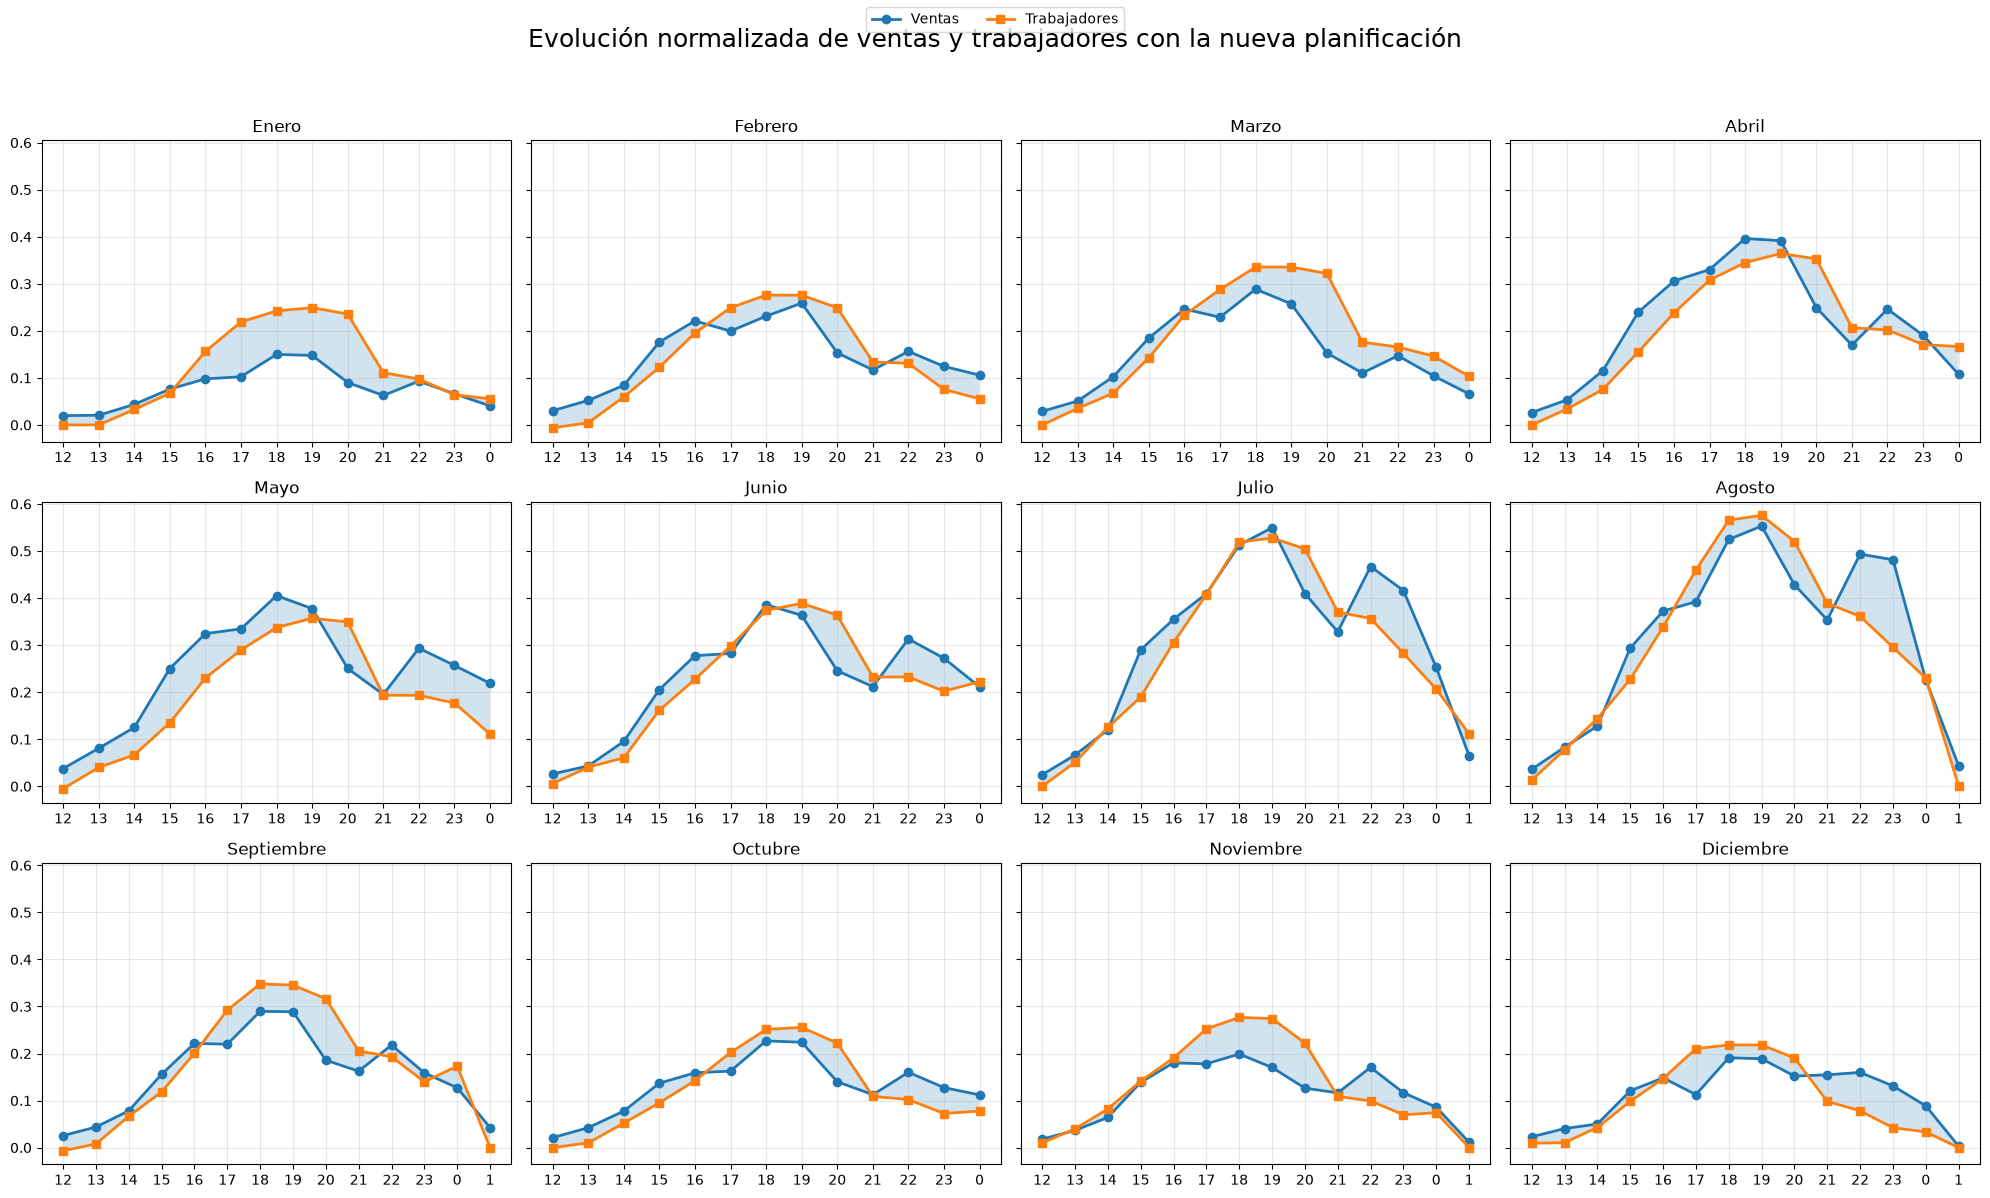

In [71]:
import matplotlib.pyplot as plt

orden_horas = [
    12, 13, 14, 15, 16, 17,
    18, 19, 20, 21, 22, 23, 0, 1
]

fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 12),
    sharey=True
)

meses = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

for mes in range(1, 13):

    datos_mes = df_nuevo[
        df_nuevo["datetime"].dt.month == mes
    ]

    comparacion = (
        datos_mes
        .groupby(
            datos_mes["datetime"].dt.hour
        )
        .agg(
            ventas_norm=("ventas_norm", "mean"),
            trabajadores_nuevo_norm=(
                "trabajadores_nuevo_norm",
                "mean"
            )
        )
        .reindex(orden_horas)
    )

    comparacion = comparacion.dropna()

    x = range(len(comparacion))

    ax = axes[
        (mes - 1) // 4,
        (mes - 1) % 4
    ]

    ax.plot(
        x,
        comparacion["ventas_norm"],
        marker="o",
        linewidth=2,
        label="Ventas"
    )

    ax.plot(
        x,
        comparacion["trabajadores_nuevo_norm"],
        marker="s",
        linewidth=2,
        label="Trabajadores"
    )

    ax.fill_between(
        x,
        comparacion["ventas_norm"],
        comparacion["trabajadores_nuevo_norm"],
        alpha=0.2
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        comparacion.index
    )

    ax.set_title(
        meses[mes - 1]
    )

    ax.grid(alpha=0.3)


fig.suptitle(
    "Evolución normalizada de ventas y trabajadores "
    "con la nueva planificación",
    fontsize=18
)

handles, labels = (
    axes[0, 0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

In [72]:
# =====================================
# MÉTRICA DE DESAJUSTE
# =====================================

import numpy as np
import pandas as pd


# -------------------------------------
# 1. Normalización común
# -------------------------------------

ventas_min = df["ventas"].min()
ventas_max = df["ventas"].max()

personas_min = df["personas"].min()
personas_max = df["personas"].max()


# Ventas
df_nuevo["ventas_norm"] = (
    (df_nuevo["ventas"] - ventas_min)
    / (ventas_max - ventas_min)
)

# Histórico
df_nuevo["historico_norm"] = (
    (df_nuevo["personas"] - personas_min)
    / (personas_max - personas_min)
)

# Nueva planificación
df_nuevo["nuevo_norm"] = (
    (df_nuevo["personas_nuevo"] - personas_min)
    / (personas_max - personas_min)
)


# -------------------------------------
# 2. Desajuste absoluto
# -------------------------------------

df_nuevo["desajuste_historico"] = (
    df_nuevo["ventas_norm"]
    - df_nuevo["historico_norm"]
).abs()

df_nuevo["desajuste_nuevo"] = (
    df_nuevo["ventas_norm"]
    - df_nuevo["nuevo_norm"]
).abs()


# -------------------------------------
# 3. Añadir mes
# -------------------------------------

df_nuevo["mes"] = (
    df_nuevo["datetime"].dt.month
)


# =====================================
# MÉTRICA GLOBAL
# =====================================

desajuste_historico_global = (
    df_nuevo["desajuste_historico"].mean()
)

desajuste_nuevo_global = (
    df_nuevo["desajuste_nuevo"].mean()
)


mejora_global = (
    (
        desajuste_historico_global
        - desajuste_nuevo_global
    )
    / desajuste_historico_global
    * 100
)


print("\n==============================")
print("MÉTRICA GLOBAL")
print("==============================")

print(
    f"Histórico:           "
    f"{desajuste_historico_global:.4f}"
)

print(
    f"Nueva planificación: "
    f"{desajuste_nuevo_global:.4f}"
)

print(
    f"Mejora:              "
    f"{mejora_global:.2f}%"
)


MÉTRICA GLOBAL
Histórico:           0.1095
Nueva planificación: 0.1075
Mejora:              1.83%


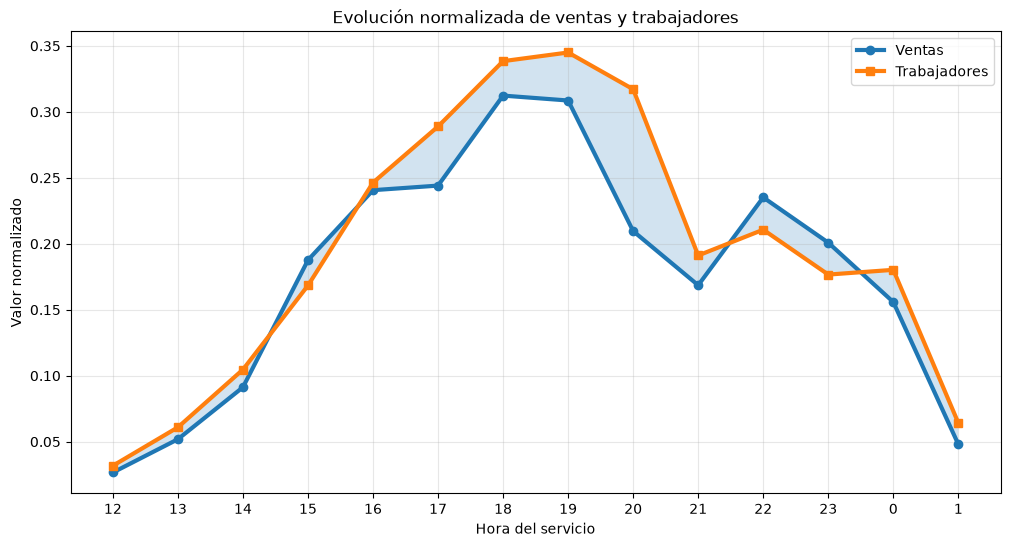

In [ ]:
# =====================================
# COMPARACIÓN VENTAS PREDICHAS -
# NUEVA PLANIFICACIÓN
# =====================================

comparacion_nueva = (
    df_nuevo
    .groupby(df_nuevo["datetime"].dt.hour)
    .agg(
        ventas_norm=("ventas_norm", "mean"),
        trabajadores_norm=("trabajadores_nuevo_norm", "mean")
    )
    .reindex(orden_horas)
    .dropna()
)

x = range(len(comparacion_nueva))

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    comparacion_nueva["ventas_norm"],
    marker="o",
    linewidth=3,
    label="Ventas"
)

plt.plot(
    x,
    comparacion_nueva["trabajadores_norm"],
    marker="s",
    linewidth=3,
    label="Trabajadores"
)

plt.fill_between(
    x,
    comparacion_nueva["ventas_norm"],
    comparacion_nueva["trabajadores_norm"],
    alpha=0.2
)

plt.xticks(
    x,
    comparacion_nueva.index.astype(str)
)

plt.xlabel("Hora del servicio")
plt.ylabel("Valor normalizado")

plt.title(
    "Evolución normalizada de ventas y trabajadores "
    "con la nueva planificación"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

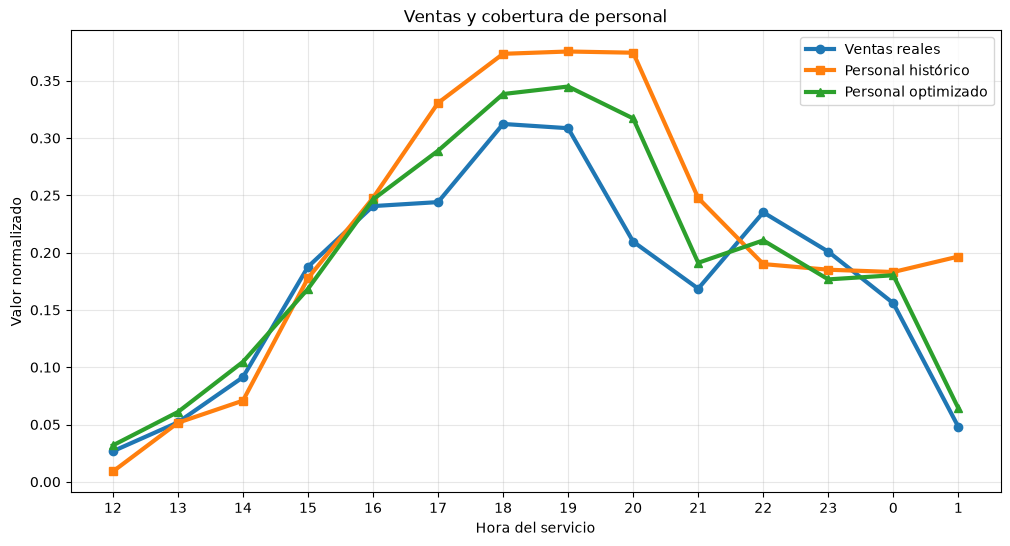

In [ ]:
# =====================================
# VENTAS + PERSONAL HISTÓRICO
# + PERSONAL OPTIMIZADO
# =====================================

comparacion = (
    df_nuevo
    .groupby(
        df_nuevo["datetime"].dt.hour
    )
    .agg(
        ventas_norm=("ventas_norm", "mean"),

        trabajadores_historico_norm=(
            "historico_norm",
            "mean"
        ),

        trabajadores_nuevo_norm=(
            "nuevo_norm",
            "mean"
        )
    )
    .reindex(orden_horas)
    .dropna()
)


x = range(len(comparacion))

plt.figure(figsize=(12, 6))


# Ventas reales

plt.plot(
    x,
    comparacion["ventas_norm"],
    marker="o",
    linewidth=3,
    label="Ventas reales"
)


# Personal histórico

plt.plot(
    x,
    comparacion["trabajadores_historico_norm"],
    marker="s",
    linewidth=3,
    label="Personal histórico"
)


# Personal optimizado

plt.plot(
    x,
    comparacion["trabajadores_nuevo_norm"],
    marker="^",
    linewidth=3,
    label="Personal optimizado"
)


plt.xticks(
    x,
    comparacion.index.astype(str)
)

plt.xlabel(
    "Hora del servicio"
)

plt.ylabel(
    "Valor normalizado"
)

plt.title(
    "Ventas y cobertura de personal"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

In [77]:
# =====================================
# DESAJUSTE MENSUAL
# HISTÓRICO VS NUEVA PLANIFICACIÓN
# =====================================

meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

metricas_mensuales = (
    df_nuevo
    .groupby("mes")
    .agg(
        desajuste_historico=(
            "desajuste_historico",
            "mean"
        ),
        desajuste_nuevo=(
            "desajuste_nuevo",
            "mean"
        )
    )
    .reset_index()
)

# Nombre del mes
metricas_mensuales["mes"] = (
    metricas_mensuales["mes"]
    .map(meses)
)

# Porcentaje de mejora
metricas_mensuales["mejora_%"] = (
    (
        metricas_mensuales["desajuste_historico"]
        - metricas_mensuales["desajuste_nuevo"]
    )
    / metricas_mensuales["desajuste_historico"]
    * 100
)

# Redondear
metricas_mensuales = metricas_mensuales.round(4)


print("\n==============================================")
print("DESAJUSTE MENSUAL: HISTÓRICO VS NUEVO")
print("==============================================")

print(
    metricas_mensuales.to_string(
        index=False
    )
)


DESAJUSTE MENSUAL: HISTÓRICO VS NUEVO
       mes  desajuste_historico  desajuste_nuevo  mejora_%
     Enero               0.0930           0.0837    9.9966
   Febrero               0.0966           0.0958    0.8218
     Marzo               0.1106           0.1330  -20.2768
     Abril               0.1114           0.1353  -21.4639
      Mayo               0.1103           0.1286  -16.5949
     Junio               0.0947           0.1218  -28.6036
     Julio               0.1043           0.1065   -2.0520
    Agosto               0.1250           0.1028   17.7583
Septiembre               0.0868           0.1003  -15.4894
   Octubre               0.1086           0.0920   15.3047
 Noviembre               0.1279           0.0838   34.5127
 Diciembre               0.1322           0.1011   23.4880
